# Step 1: Setup

In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [23]:
# Loading the dataset and displaying the first few rows

# Load the dataset
data = pd.read_csv('heart.csv')

# Data Information
print("Dataset Shape:", data.shape)
print(data.info())
print("\nSample data:")
print(data.head())
print("\nDescriptive Statistics:")
print(data.describe())

# Label numerical and categorical features
cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Dataset Shape: (918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Sample data:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172

In [24]:
# Splitting data (70% training, 15% validation, 15% test)

# Separating the features and target
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

# Split into train and temporary sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split the temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} ({X_train.shape[0]/len(X):.1%})")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X):.1%})")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X):.1%})")


Training set size: 642 (69.9%)
Validation set size: 138 (15.0%)
Test set size: 138 (15.0%)


In [25]:
# This preprocessing pipeline standardizes numerical features and one-hot encodes categorical features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)

# The processed features are combined with the target variable for heart disease prediction analysis.
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cats = list(cat_encoder.get_feature_names_out(cat_features))
feature_names = num_features + encoded_cats

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

train_data = X_train_processed_df.copy()
train_data['HeartDisease'] = y_train.values.reshape(-1)

print("\nProcessed training data shape:", X_train_processed.shape)


Processed training data shape: (642, 15)


# Step 2: Unsupervised Analysis

In [26]:
# K-means Clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_processed)

# PCA (Diamensionality)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_train_processed)

# Combining PCA components with cluster assignments and target variable for visualization
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters
pca_df['HeartDisease'] = y_train.values

Visualizations

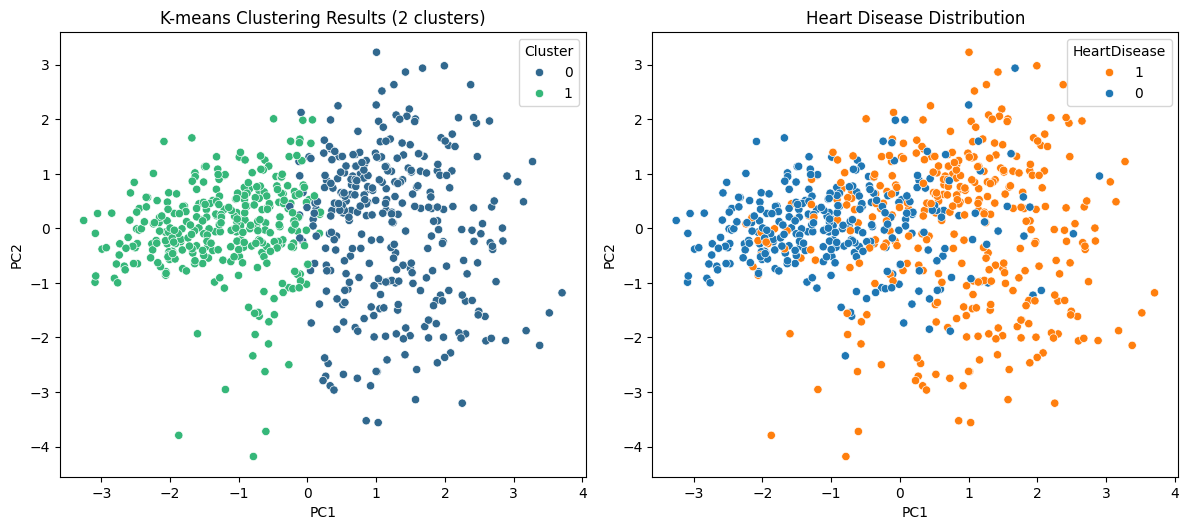

In [27]:
disease_palette = {"0": "#1f77b4", "1": "#ff7f0e"} # Orange and Blue color

# Clustering with PCA
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis')
plt.title('K-means Clustering Results (2 clusters)')

# Plot showing heart disease status
pca_df['HeartDisease'] = pca_df['HeartDisease'].astype(str)
plt.subplot(2, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='HeartDisease', data=pca_df, palette=disease_palette)
plt.title('Heart Disease Distribution')
plt.tight_layout()
plt.show()

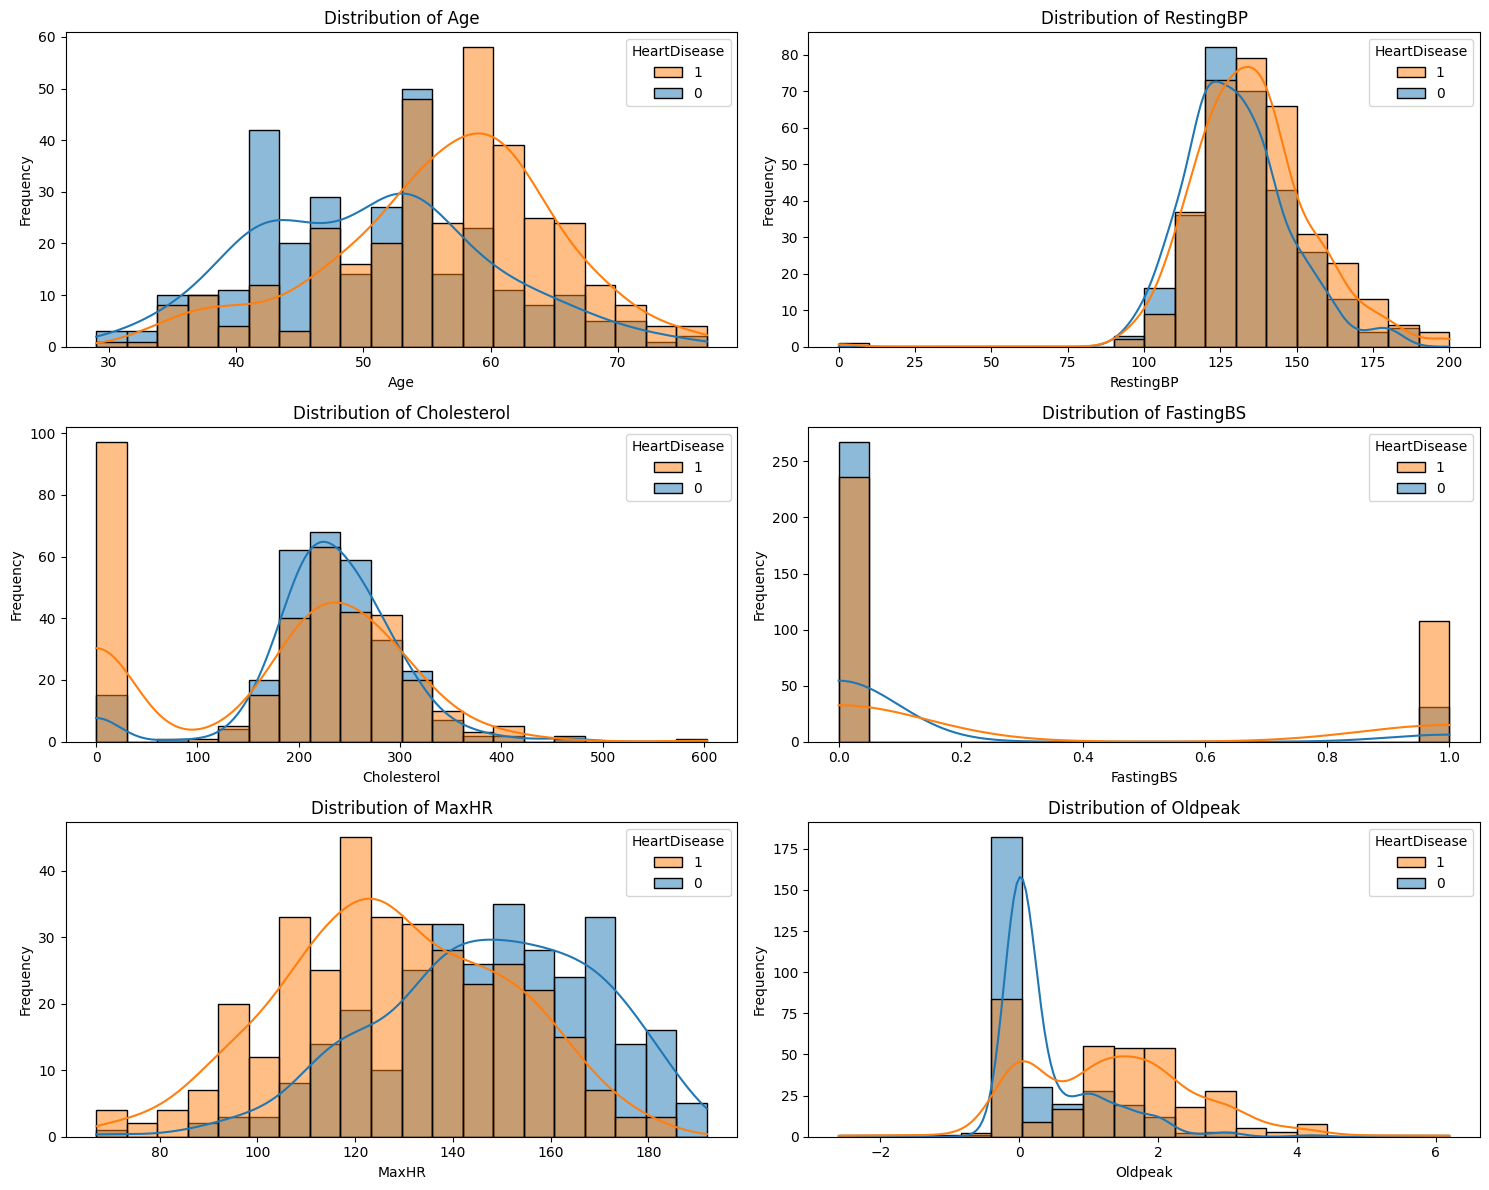

In [28]:
# Histograms of numerical features

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()
for i, feature in enumerate(num_features):
    if i < len(axes):
        y_train_str = y_train.astype(str)
        sns.histplot(data=X_train, x=feature, hue=y_train_str, bins=20, kde=True, palette=disease_palette, ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}') # Feature title (x-axis)
        axes[i].set_ylabel('Frequency') # Frequency label (y-axis)

plt.tight_layout()
plt.show()

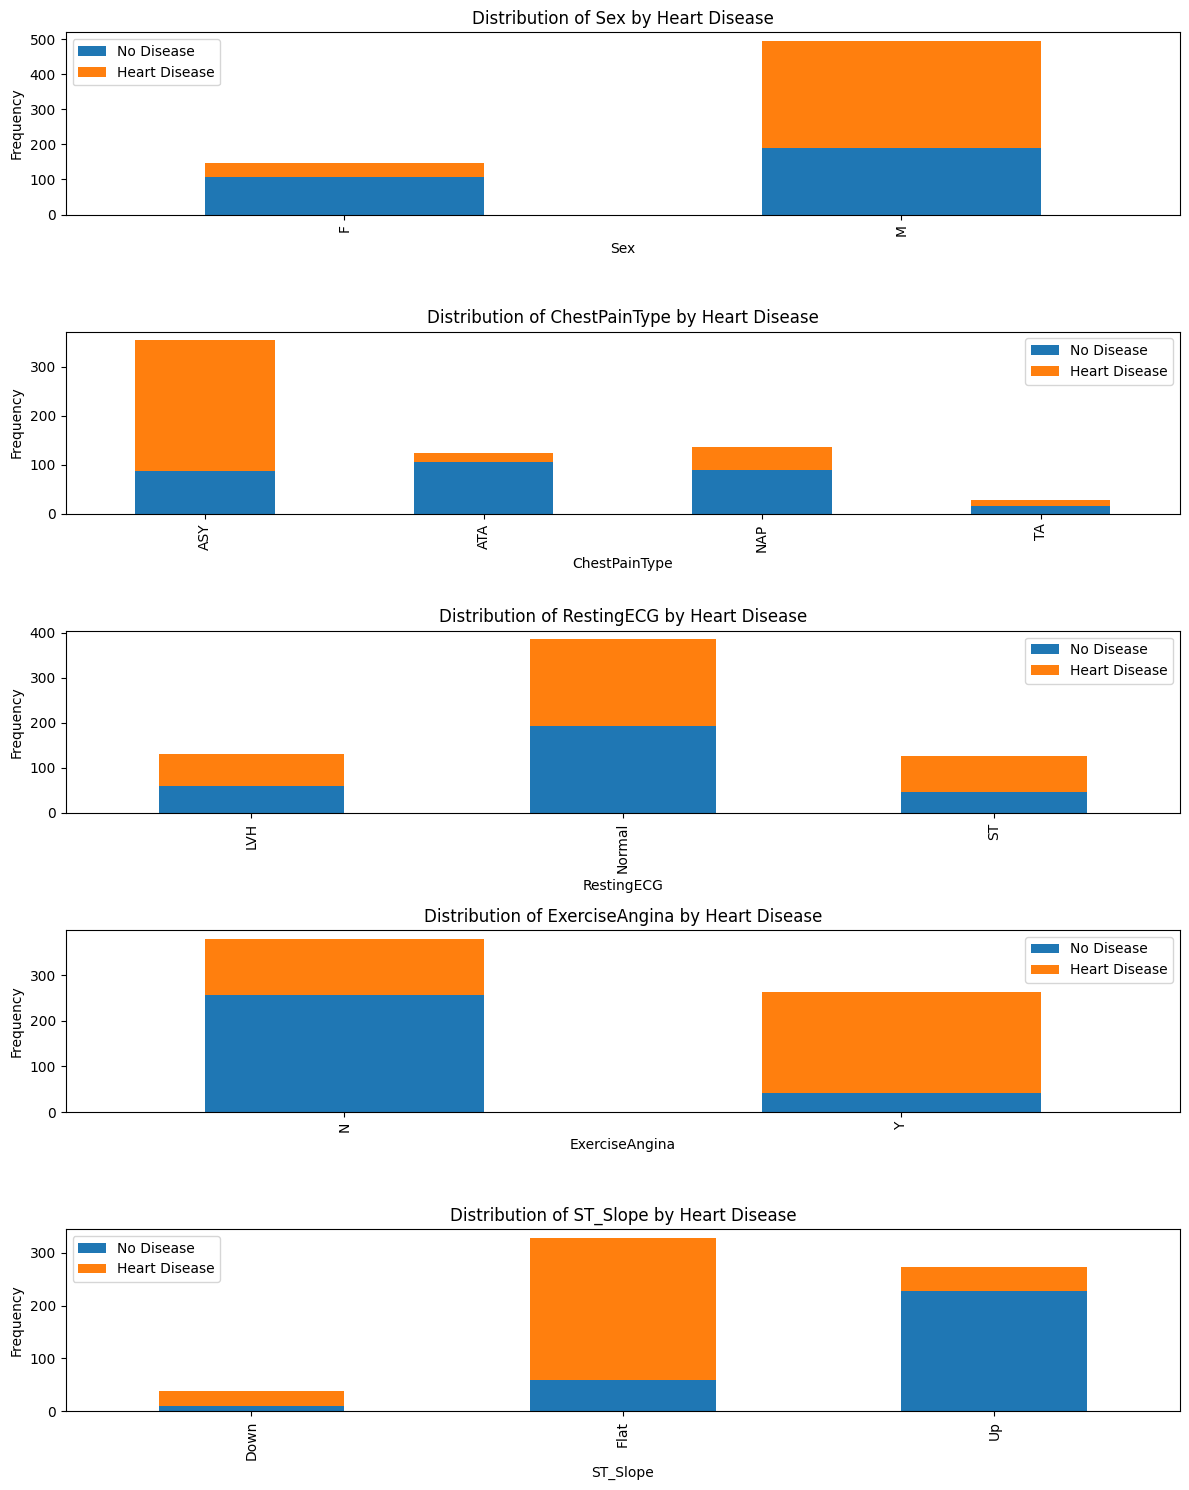

In [29]:
# Categorical feature distributions

fig, axes = plt.subplots(len(cat_features), 1, figsize=(12, 15))
disease_colors = [disease_palette["0"], disease_palette["1"]]

for i, feature in enumerate(cat_features):
    crosstab = pd.crosstab(X_train[feature], y_train)
    crosstab.plot(kind='bar', stacked=True, ax=axes[i], color=disease_colors)
    axes[i].set_title(f'Distribution of {feature} by Heart Disease') # Feature title (x-axis)
    axes[i].set_ylabel('Frequency') # Frequency label (y-axis)
    axes[i].legend(['No Disease', 'Heart Disease'])

plt.tight_layout()
plt.show()

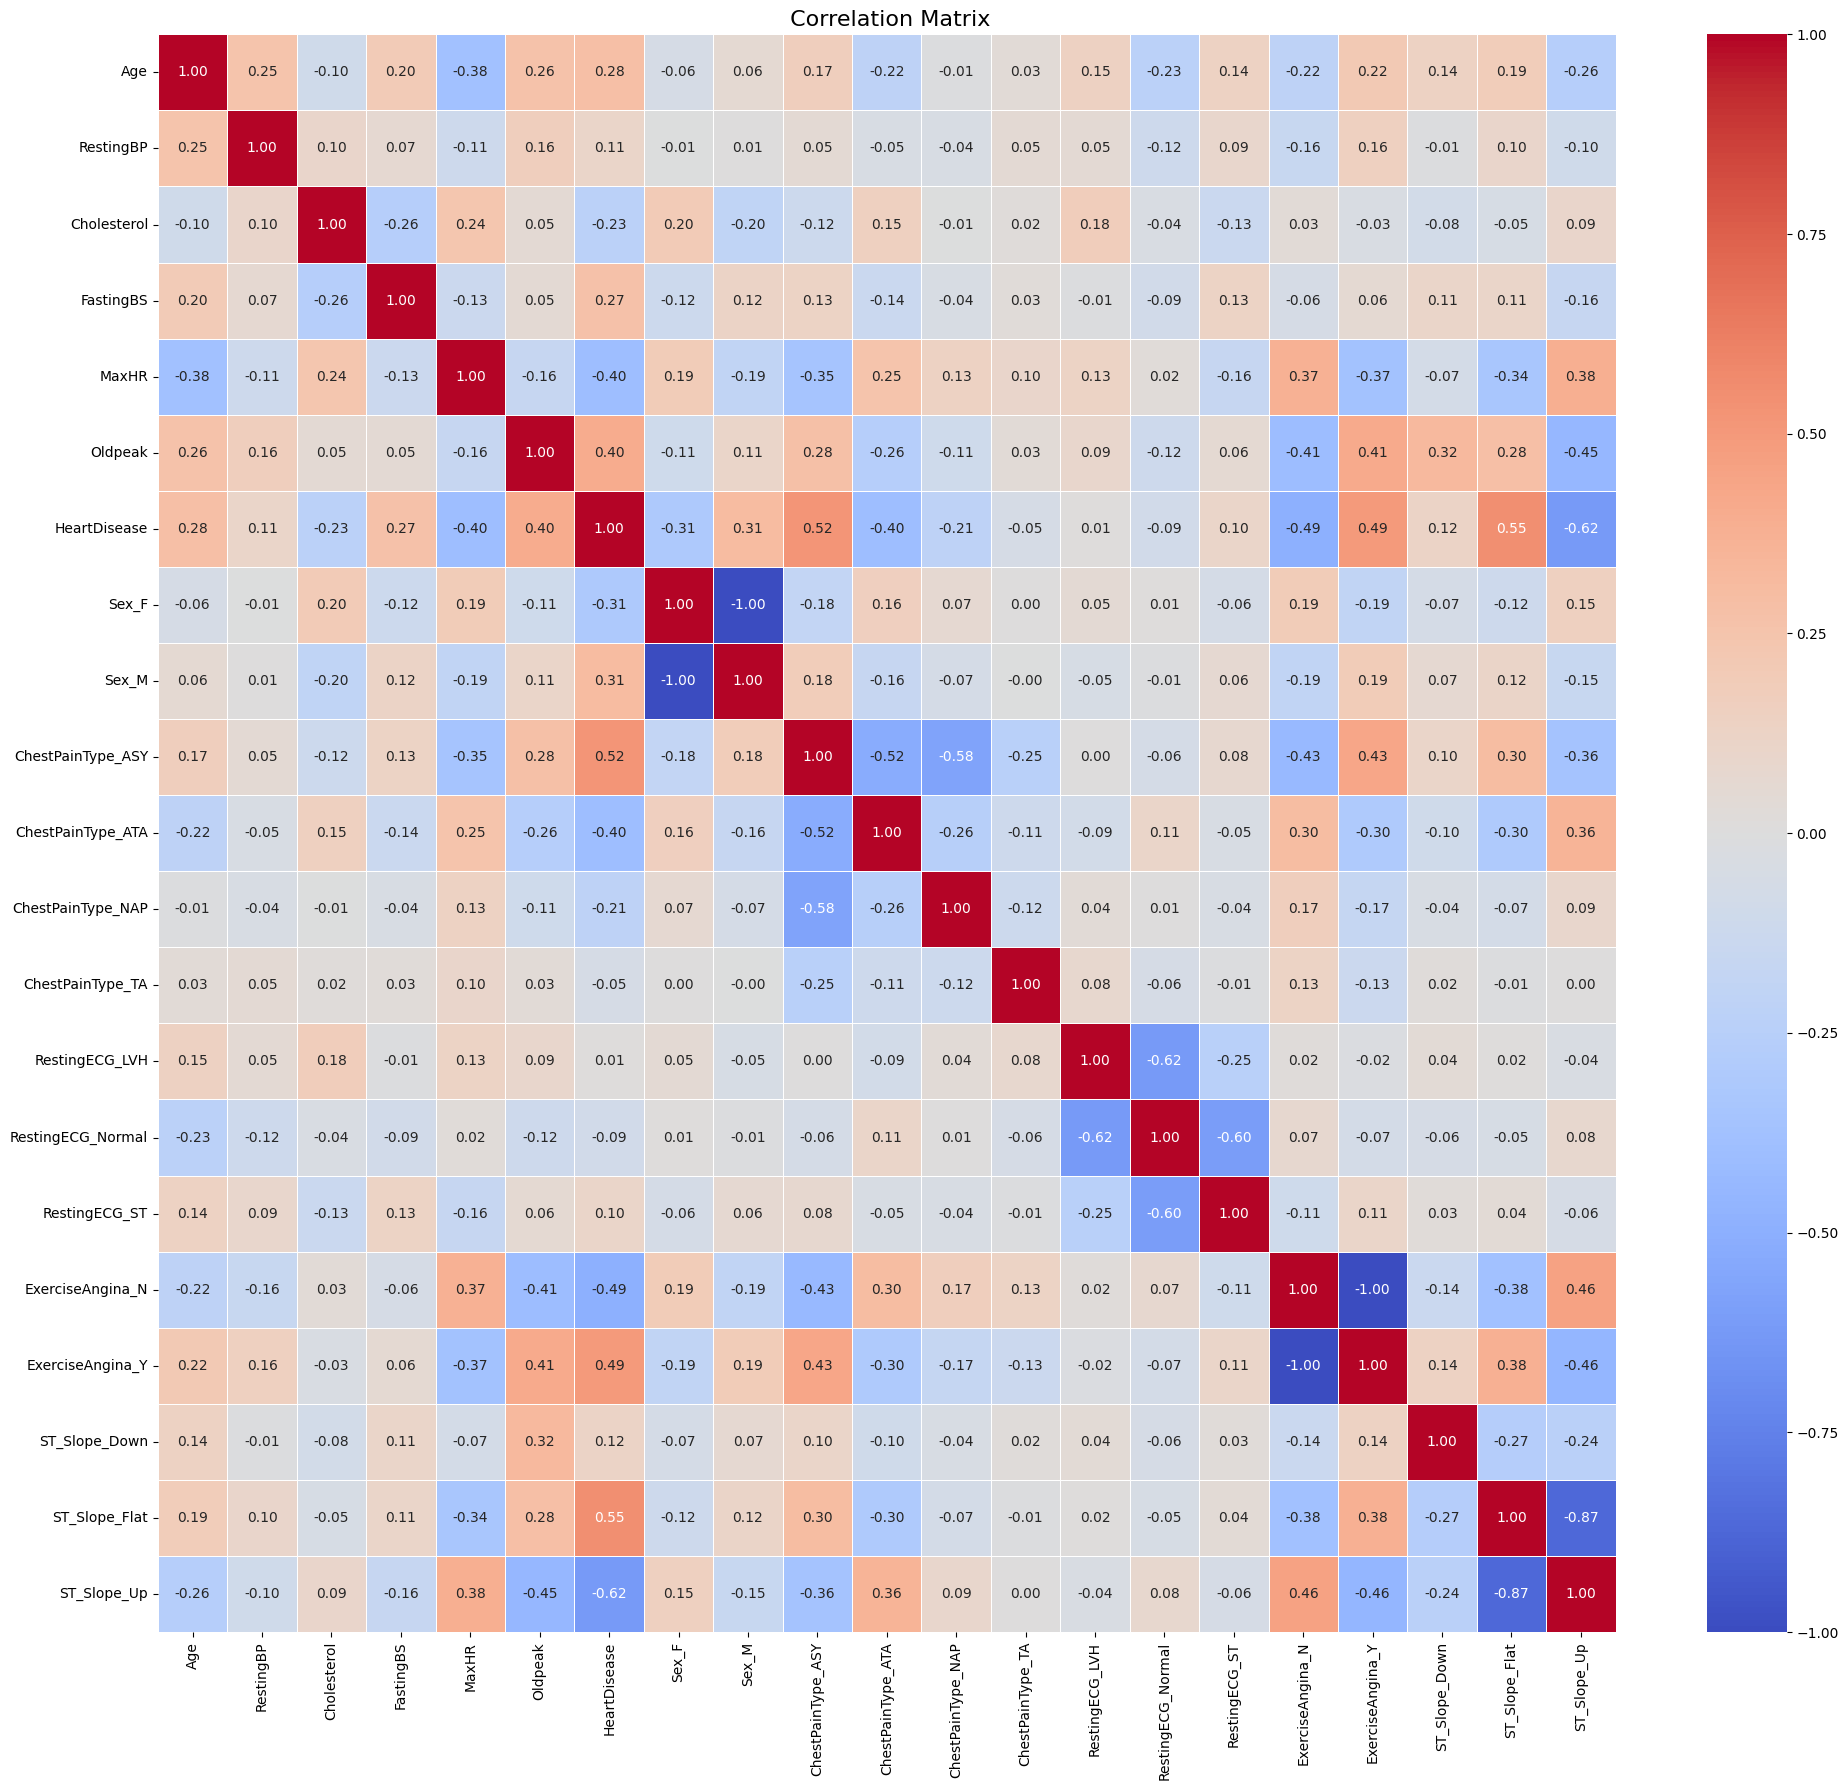

In [30]:
# Correlation Matrix 

data_encoded = pd.get_dummies(data, columns=cat_features, drop_first=False)
correlation = data_encoded.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(' Correlation Matrix', fontsize=16)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Step 3 & 4: Supervised Analysis and Results

In [ ]:
# Import extra libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='keras')
np.random.seed(42)
tf.random.set_seed(42)

# Preprocessing datasets
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)
X_val_processed_df = pd.DataFrame(X_val_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Function to evaluate and store model performance
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name, transform_name, reg_value):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)  

    train_precision = precision_score(y_train, y_train_pred)
    val_precision = precision_score(y_val, y_val_pred)
    test_precision = precision_score(y_test, y_test_pred)
    
    train_recall = recall_score(y_train, y_train_pred)
    val_recall = recall_score(y_val, y_val_pred)
    test_recall = recall_score(y_test, y_test_pred)

    train_f1 = f1_score(y_train, y_train_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Store results in a dict
    results = {
        'model': model_name,
        'transform': transform_name,
        'regularization': reg_value,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'test_accuracy': test_accuracy,
        'train_precision': train_precision,
        'val_precision': val_precision,
        'test_precision': test_precision,
        'train_recall': train_recall,
        'val_recall': val_recall,
        'test_recall': test_recall,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'test_f1': test_f1
    }
    
    return results

# Results list
results_list = []

Logistic Regression

In [33]:
# Regularization values
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# Original
print("\nLogistic Regression - No Transformation")
for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    results = evaluate_model(model, X_train_processed, y_train, X_val_processed, y_val, X_test_processed, y_test, 'Logistic Regression', 'No Transform', C)
    results_list.append(results)
    print(f"C={C}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")

# Polynomial degree 2
print("\nLogistic Regression - Polynomial Degree 2")
for C in C_values:
    poly2 = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly2 = poly2.fit_transform(X_train_processed)
    X_val_poly2 = poly2.transform(X_val_processed)
    X_test_poly2 = poly2.transform(X_test_processed)
    model = LogisticRegression(C=C, max_iter=2000, random_state=42)
    results = evaluate_model(model, X_train_poly2, y_train, X_val_poly2, y_val, X_test_poly2, y_test, 'Logistic Regression', 'Polynomial Degree 2', C)
    
    results_list.append(results)
    print(f"C={C}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")

# Polynomial degree 3
print("\nLogistic Regression - Polynomial Degree 3")
for C in C_values:
    poly3 = PolynomialFeatures(degree=3, include_bias=False)
    X_train_poly3 = poly3.fit_transform(X_train_processed)
    X_val_poly3 = poly3.transform(X_val_processed)
    X_test_poly3 = poly3.transform(X_test_processed)
    model = LogisticRegression(C=C, max_iter=3000, random_state=42)
    results = evaluate_model(model, X_train_poly3, y_train, X_val_poly3, y_val, X_test_poly3, y_test, 'Logistic Regression', 'Polynomial Degree 3', C)
    
    results_list.append(results)
    print(f"C={C}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")

# PCA transformation
print("\nLogistic Regression - PCA")
n_components = min(10, X_train_processed.shape[1])  
pca_transform = PCA(n_components=n_components)
X_train_pca = pca_transform.fit_transform(X_train_processed)
X_val_pca = pca_transform.transform(X_val_processed)
X_test_pca = pca_transform.transform(X_test_processed)

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    results = evaluate_model(model, X_train_pca, y_train, X_val_pca, y_val, X_test_pca, y_test, 'Logistic Regression', 'PCA', C)
    results_list.append(results)
    print(f"C={C}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")



Logistic Regression - No Transformation
C=0.001, Training Accuracy: 0.8100, Validation Accuracy: 0.8116, Test Accuracy: 0.7826
C=0.01, Training Accuracy: 0.8442, Validation Accuracy: 0.8623, Test Accuracy: 0.8478
C=0.1, Training Accuracy: 0.8598, Validation Accuracy: 0.8696, Test Accuracy: 0.8768
C=1.0, Training Accuracy: 0.8645, Validation Accuracy: 0.8768, Test Accuracy: 0.8913
C=10.0, Training Accuracy: 0.8614, Validation Accuracy: 0.8696, Test Accuracy: 0.8913
C=100.0, Training Accuracy: 0.8614, Validation Accuracy: 0.8696, Test Accuracy: 0.8913

Logistic Regression - Polynomial Degree 2
C=0.001, Training Accuracy: 0.8442, Validation Accuracy: 0.8623, Test Accuracy: 0.8406
C=0.01, Training Accuracy: 0.8754, Validation Accuracy: 0.8768, Test Accuracy: 0.8841
C=0.1, Training Accuracy: 0.8925, Validation Accuracy: 0.8986, Test Accuracy: 0.8913
C=1.0, Training Accuracy: 0.9050, Validation Accuracy: 0.9130, Test Accuracy: 0.8768
C=10.0, Training Accuracy: 0.9128, Validation Accuracy: 0

SVM

In [34]:
# No transformation (baseline with linear kernel)
print("\nSVM - Linear Kernel (No Transformation)")
for C in C_values:
    model = SVC(C=C, kernel='linear', random_state=42)
    results = evaluate_model(model, X_train_processed, y_train, X_val_processed, y_val, X_test_processed, y_test, 'SVM', 'Linear Kernel', C)
    results_list.append(results)
    print(f"C={C}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")

# Polynomial degree 2
print("\nSVM - Polynomial Degree 2")
for C in C_values:
    model = SVC(C=C, kernel='poly', degree=2, random_state=42)
    results = evaluate_model(model, X_train_processed, y_train, X_val_processed, y_val, X_test_processed, y_test, 'SVM', 'Polynomial Degree 2', C)
    results_list.append(results)
    print(f"C={C}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")


# PCA transformation
print("\nSVM - PCA")
for C in C_values:
    model = SVC(C=C, kernel='linear', random_state=42)
    results = evaluate_model(model, X_train_pca, y_train, X_val_pca, y_val, X_test_pca, y_test, 'SVM', 'PCA', C)
    results_list.append(results)
    print(f"C={C}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")

# RBF Kernel
print("\nSVM - RBF Kernel")
for C in C_values:
    model = SVC(C=C, kernel='rbf', random_state=42)
    results = evaluate_model(model, X_train_processed, y_train, X_val_processed, y_val, X_test_processed, y_test, 'SVM', 'RBF Kernel', C)
    results_list.append(results)
    print(f"C={C}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")



SVM - Linear Kernel (No Transformation)
C=0.001, Training Accuracy: 0.8287, Validation Accuracy: 0.8188, Test Accuracy: 0.8333
C=0.01, Training Accuracy: 0.8489, Validation Accuracy: 0.8478, Test Accuracy: 0.8696
C=0.1, Training Accuracy: 0.8567, Validation Accuracy: 0.8478, Test Accuracy: 0.8768
C=1.0, Training Accuracy: 0.8629, Validation Accuracy: 0.8551, Test Accuracy: 0.8913
C=10.0, Training Accuracy: 0.8583, Validation Accuracy: 0.8623, Test Accuracy: 0.8913
C=100.0, Training Accuracy: 0.8598, Validation Accuracy: 0.8551, Test Accuracy: 0.8913

SVM - Polynomial Degree 2
C=0.001, Training Accuracy: 0.5358, Validation Accuracy: 0.5870, Test Accuracy: 0.6014
C=0.01, Training Accuracy: 0.6526, Validation Accuracy: 0.6739, Test Accuracy: 0.6884
C=0.1, Training Accuracy: 0.8692, Validation Accuracy: 0.8768, Test Accuracy: 0.8623
C=1.0, Training Accuracy: 0.8863, Validation Accuracy: 0.8551, Test Accuracy: 0.8841
C=10.0, Training Accuracy: 0.9019, Validation Accuracy: 0.8986, Test Accu

Neural Network

In [35]:
# Function to create and train neural network models
def create_and_evaluate_nn(X_train, y_train, X_val, y_val, X_test, y_test, architecture, reg_value):
    X_train_np = X_train.copy()
    X_val_np = X_val.copy()
    X_test_np = X_test.copy()
    
    if isinstance(X_train, pd.DataFrame):
        X_train_np = X_train.values
    if isinstance(X_val, pd.DataFrame):
        X_val_np = X_val.values
    if isinstance(X_test, pd.DataFrame):
        X_test_np = X_test.values  
    
   
    model = Sequential()
    input_dim = X_train_np.shape[1]
    
    # Apply L2 reg
    regularizer = l2(reg_value)
    
    # Add input layer
    for i, units in enumerate(architecture):
        if i == 0:
            model.add(Dense(units, input_dim=input_dim, activation='relu', kernel_regularizer=regularizer))
        else:
            model.add(Dense(units, activation='relu', kernel_regularizer=regularizer))
    
    # Add output layer
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(learning_rate=0.001), 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(
        X_train_np, y_train, 
        epochs=100, 
        batch_size=32, 
        validation_data=(X_val_np, y_val),
        callbacks=[early_stop],
        verbose=0
    )
    
    # Evaluate model
    train_results = model.evaluate(X_train_np, y_train, verbose=0)
    val_results = model.evaluate(X_val_np, y_val, verbose=0)
    test_results = model.evaluate(X_test_np, y_test, verbose=0)
    
    # Get predictions (for precision and recall)
    y_train_pred = (model.predict(X_train_np) > 0.5).astype(int).flatten()
    y_val_pred = (model.predict(X_val_np) > 0.5).astype(int).flatten()
    y_test_pred = (model.predict(X_test_np) > 0.5).astype(int).flatten()
    
    train_precision = precision_score(y_train, y_train_pred)
    val_precision = precision_score(y_val, y_val_pred)
    test_precision = precision_score(y_test, y_test_pred)
    
    train_recall = recall_score(y_train, y_train_pred)
    val_recall = recall_score(y_val, y_val_pred)
    test_recall = recall_score(y_test, y_test_pred)

    train_f1 = f1_score(y_train, y_train_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Architecture description
    arch_desc = f"NN_{'-'.join(map(str, architecture))}"
    
    results = {
        'model': 'Neural Network',
        'transform': arch_desc,
        'regularization': reg_value,
        'train_accuracy': train_results[1],
        'val_accuracy': val_results[1],
        'test_accuracy': test_results[1], 
        'train_precision': train_precision,
        'val_precision': val_precision,
        'test_precision': test_precision, 
        'train_recall': train_recall,
        'val_recall': val_recall,
        'test_recall': test_recall,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'history': history.history
    }
    
    return results

nn_reg_values = [0.0, 0.0001, 0.001, 0.01, 0.1, 0.5]


architectures = [
    [16],               # 1 hidden layer (16 neurons)
    [32, 16],           # 2 hidden layers (32 and 16 neurons)
    [64, 32, 16]        # 3 hidden layers (64, 32, and 16 neurons)
]

# Results list
nn_results = []

for arch in architectures:
    arch_desc = f"NN_{'-'.join(map(str, arch))}"
    print(f"\nNeural Network - {arch_desc}")
    
    for reg_value in nn_reg_values:
        results = create_and_evaluate_nn(X_train_processed, y_train, X_val_processed, y_val, X_test_processed, y_test, arch, reg_value)
        nn_results.append(results)
        print(f"L2 Reg={reg_value}, Training Accuracy: {results['train_accuracy']:.4f}, Validation Accuracy: {results['val_accuracy']:.4f}, Test Accuracy: {results['test_accuracy']:.4f}")

# Add results
results_list.extend(nn_results)

results_df = pd.DataFrame(results_list)

results_df.to_csv('model_results.csv', index=False)



Neural Network - NN_16
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
L2 Reg=0.0, Training Accuracy: 0.8910, Validation Accuracy: 0.8768, Test Accuracy: 0.8696
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
L2 Reg=0.0001, Training Accuracy: 0.8956, Validation Accuracy: 0.8623, Test Accuracy: 0.8841
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
L2 Reg=0.001, Training Accuracy: 0.8769, Validation Accuracy: 0.8623, Test Accuracy: 0.8768
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
L2 Reg=0.01, Training Accuracy: 0.8801, Validation Accuracy: 0.8696, Test Accuracy: 0.8696
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
L2 Reg=0.1, Training Accuracy: 0.

# Step 4: Conclusion

In [ ]:
print("\n=== Best Test Accuracy Within Each Model Type ===")
# Group by 'model' and 'transform', then find the one with max test_accuracy
best_models = results_df.loc[results_df.groupby(['model', 'transform'])['test_accuracy'].idxmax()]
best_models = best_models.sort_values(by='test_accuracy', ascending=False)

# Display the best model for each model type
model_transform_pairs = results_df[['model', 'transform']].drop_duplicates()
for _, row in model_transform_pairs.iterrows():
    mask = (results_df['model'] == row['model']) & (results_df['transform'] == row['transform'])
    best_idx = results_df[mask]['test_accuracy'].idxmax()
    best_row = results_df.loc[best_idx]
    print(f"{best_row['model']} - {best_row['transform']}: Test Accuracy = {best_row['test_accuracy']:.4f}, " 
          f"F1 Score = {best_row.get('test_f1', 'N/A'):.4f}, Regularization = {best_row['regularization']}")

# Display the top 5 models overall (by test accuracy)
print("\n=== Top 5 Test Accuracy Across All Models ===")
top5_models = results_df.sort_values(by='test_accuracy', ascending=False).head(5)
for idx, row in top5_models.iterrows():
    print(f"Rank {idx+1}: {row['model']} - {row['transform']} (Reg={row['regularization']}): "
          f"Test Accuracy = {row['test_accuracy']:.4f}, F1 Score = {row.get('test_f1', 'N/A'):.4f}")


=== Best Test Accuracy Within Each Model Type ===
Logistic Regression - No Transform: Test Accuracy = 0.8913, F1 Score = 0.9080, Regularization = 1.0
Logistic Regression - Polynomial Degree 2: Test Accuracy = 0.8913, F1 Score = 0.9102, Regularization = 0.1
Logistic Regression - Polynomial Degree 3: Test Accuracy = 0.8841, F1 Score = 0.9012, Regularization = 0.01
Logistic Regression - PCA: Test Accuracy = 0.8768, F1 Score = 0.8944, Regularization = 10.0
SVM - Linear Kernel: Test Accuracy = 0.8913, F1 Score = 0.9080, Regularization = 1.0
SVM - Polynomial Degree 2: Test Accuracy = 0.8841, F1 Score = 0.9036, Regularization = 1.0
SVM - PCA: Test Accuracy = 0.8623, F1 Score = 0.8862, Regularization = 0.01
SVM - RBF Kernel: Test Accuracy = 0.8623, F1 Score = 0.8862, Regularization = 1.0
Neural Network - NN_16: Test Accuracy = 0.8841, F1 Score = 0.9024, Regularization = 0.0001
Neural Network - NN_32-16: Test Accuracy = 0.8768, F1 Score = 0.8944, Regularization = 0.0001
Neural Network - NN_64-